In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
!pip install numpy pandas matplotlib minisom

In [11]:
import os
import numpy as np
from PIL import Image
import pandas as pd
import tensorflow as tf
from minisom import MiniSom
import ast
import matplotlib.pyplot as plt

In [12]:
############################################################################################
image_dir = '/content/drive/MyDrive/Colab Notebooks/downloaded_images/'
main_dir = '/content/drive/MyDrive/Colab Notebooks/'
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/image_features_vgg16.csv'
############################################################################################
# Load the CSV file
data = pd.read_csv(csv_file_path)

In [13]:
# Extract filenames and convert stringified lists to actual lists
filenames = data.iloc[:, 0].values
features = data.iloc[:, 1].apply(ast.literal_eval).tolist()
features = np.array(features)

In [14]:
# set parameters for SOM
m = 7
map_size = (m, m)
input_len = features.shape[1]
sigma = 1.0
learning_rate = 0.5
num_epochs = 100

In [15]:
# initialize SOM
som = MiniSom(map_size[0], map_size[1], input_len, sigma=sigma, learning_rate=learning_rate,
              activation_distance='cosine', random_seed=42)
# som.pca_weights_init(features)
som.random_weights_init(features)
# train SOM
som.train_random(features, len(features), verbose=True)
# determine best matching units for each image
bmu_indices = np.array([som.winner(x) for x in features])

 [ 203 / 203 ] 100% - 0:00:00 left 
 quantization error: 857.419519036936


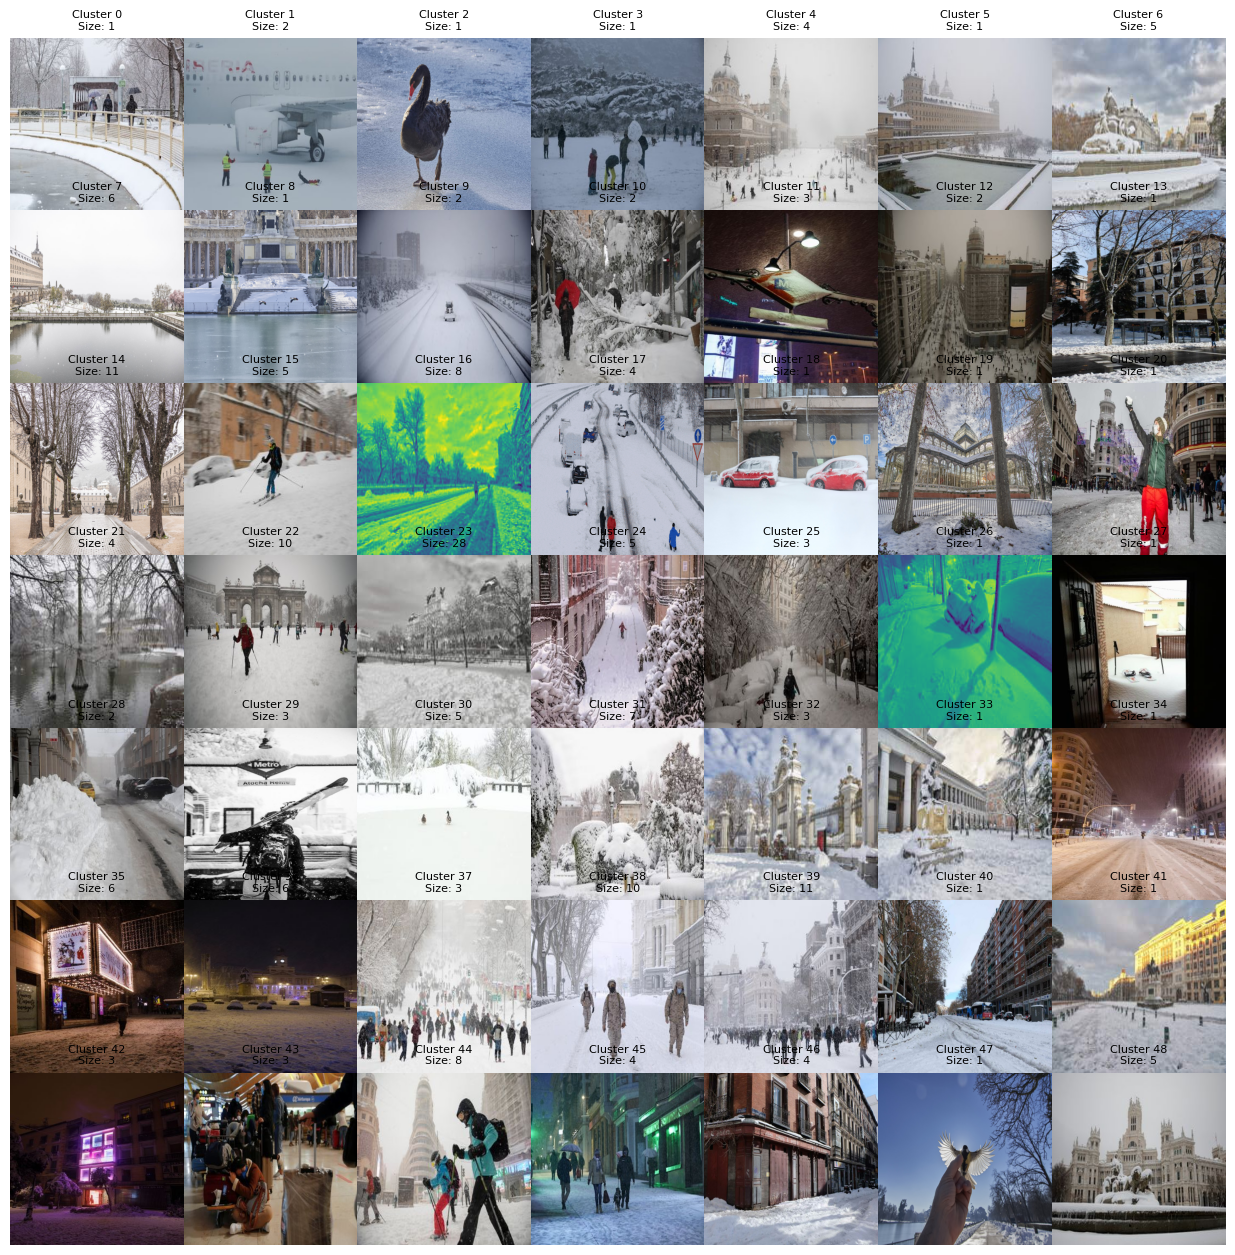

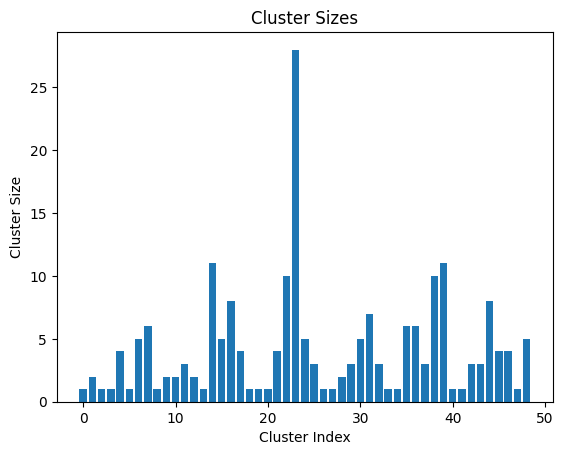

In [16]:
# Define grid size
dpi = 100
subplot_size = 224
figsize = (m * subplot_size / dpi, m * subplot_size / dpi)

# Create a figure with 10x10 subplots
fig, axes = plt.subplots(m, m, figsize=figsize)

# Create a list to keep track of cluster sizes
cluster_sizes = []

# Plot each image in the 10x10 grid
for i in range(m):
    for j in range(m):
        # Get the index of the current SOM node (BMU)
        index = i * m + j

        # Get the list of image indices corresponding to this BMU (i, j)
        bmu_images_indices = [idx for idx, bmu in enumerate(bmu_indices) if tuple(bmu) == (i, j)]

        # Append cluster size to the list
        cluster_sizes.append(len(bmu_images_indices))

        # Plot the first image in the cluster (you can customize this)
        if len(bmu_images_indices) > 0:
            # Load the first image for this BMU
            img_index = bmu_images_indices[0]  # You can loop through all images if needed
            img = Image.open(image_dir + '/' + filenames[img_index])  # Load the image from filename

            # Display the image without black borders and set aspect ratio to 'auto'
            axes[i, j].imshow(img, aspect='auto')
        else:
            # In case of empty clusters, display a placeholder or a message
            axes[i, j].text(0.5, 0.5, "Empty Cluster", ha="center", va="center")

        # Add a title with the cluster index and size
        axes[i, j].set_title(f'Cluster {index}\nSize: {len(bmu_images_indices)}', fontsize=8)

        # Remove the axis ticks for a cleaner look
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

        # Hide borders around the images
        axes[i, j].spines['top'].set_visible(False)
        axes[i, j].spines['right'].set_visible(False)
        axes[i, j].spines['left'].set_visible(False)
        axes[i, j].spines['bottom'].set_visible(False)

# Adjust layout to remove padding between images
plt.subplots_adjust(wspace=0, hspace=0)

# Save the figure to a file
plt.savefig('grid_som_10x10_no_borders.png', bbox_inches='tight', pad_inches=0)

# Visualize cluster sizes as a bar chart
plt.figure()
plt.bar(range(m * m), cluster_sizes)
plt.xlabel('Cluster Index')
plt.ylabel('Cluster Size')
plt.title('Cluster Sizes')
plt.savefig('cluster_sizes.png')

plt.show()

In [18]:
# Assuming 'filenames' contains the image paths and 'bmu_indices' has the cluster labels
data_for_csv = []

# Loop through each image and associate it with the corresponding cluster
for idx, bmu in enumerate(bmu_indices):
    # Construct the image path
    image_path = os.path.join(image_dir, filenames[idx])
    # Convert BMU coordinates to a single numeric label
    cluster_label = bmu[0] * m + bmu[1]
    # Store the image path and its numeric label
    data_for_csv.append([image_path, cluster_label])

# Create a DataFrame and save it as a CSV
df = pd.DataFrame(data_for_csv, columns=["image_path", "cluster_label"])
csv_output_path = "/content/clustered_images_whole_data.csv"  # Adjust path as needed
df.to_csv(csv_output_path, index=False)

print(f"CSV file saved at: {csv_output_path}")


CSV file saved at: /content/clustered_images_whole_data.csv


In [48]:
import pandas as pd

# Load the CSV with image paths and numeric labels
csv_path = "/content/clustered_images_whole_data.csv"  # Update with the correct path
df = pd.read_csv(csv_path)

# Choose multiple specific labels for multi-class classification
selected_labels = [14,22,38,39]  # Example: update with your desired labels

# Filter the dataframe to include only the selected labels
multi_df = df[df['cluster_label'].isin(selected_labels)].copy()

# Map the selected labels to consecutive integers for multi-class classification
label_mapping = {label: idx for idx, label in enumerate(selected_labels)}
multi_df['multi_label'] = multi_df['cluster_label'].map(label_mapping)

print(multi_df.head())  # Display the filtered data

                                           image_path  cluster_label  \
2   /content/drive/MyDrive/Colab Notebooks/downloa...             39   
6   /content/drive/MyDrive/Colab Notebooks/downloa...             39   
23  /content/drive/MyDrive/Colab Notebooks/downloa...             39   
25  /content/drive/MyDrive/Colab Notebooks/downloa...             22   
30  /content/drive/MyDrive/Colab Notebooks/downloa...             22   

    multi_label  
2             3  
6             3  
23            3  
25            1  
30            1  


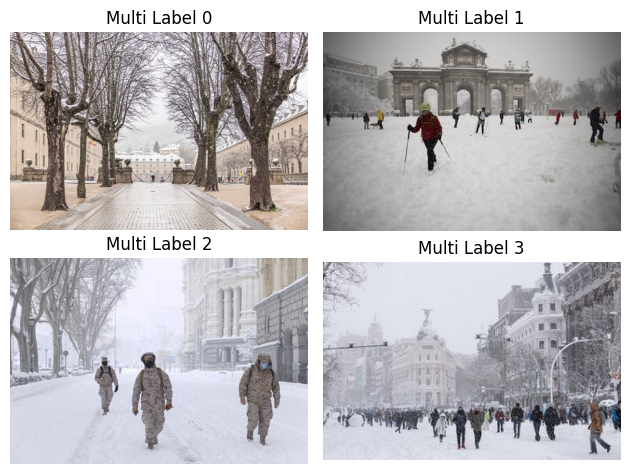

In [49]:
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
# Example: Loading the DataFrame (replace this with your actual DataFrame loading if needed)
# binary_df = pd.read_csv('your_dataset.csv')

# Select one image path for each binary label
img_path_label_0 = multi_df[multi_df['multi_label'] == 0].iloc[0]['image_path']
img_path_label_1 = multi_df[multi_df['multi_label'] == 1].iloc[0]['image_path']
img_path_label_2 = multi_df[multi_df['multi_label'] == 2].iloc[0]['image_path']
img_path_label_3 = multi_df[multi_df['multi_label'] == 3].iloc[0]['image_path']

# Open and display the images
img_0 = Image.open(img_path_label_0)
img_1 = Image.open(img_path_label_1)
img_2 = Image.open(img_path_label_2)
img_3 = Image.open(img_path_label_3)

# Display images inline
fig, axs = plt.subplots(2, 2)

axs[0,0].imshow(img_0)
axs[0,0].set_title('Multi Label 0')
axs[0,0].axis('off')

axs[0,1].imshow(img_1)
axs[0,1].set_title('Multi Label 1')
axs[0,1].axis('off')

axs[1,0].imshow(img_2)
axs[1,0].set_title('Multi Label 2')
axs[1,0].axis('off')

axs[1,1].imshow(img_3)
axs[1,1].set_title('Multi Label 3')
axs[1,1].axis('off')

plt.tight_layout()
plt.show()

In [50]:
multi_df['multi_label'].value_counts()

,count
multi_label,
3,11
0,11
1,10
2,10


In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
import numpy as np

# Load images and prepare the data for multi-class classification
def load_and_preprocess_images(df, target_size=(224, 224)):
    images = []
    labels = []
    for _, row in df.iterrows():
        img = load_img(row['image_path'], target_size=target_size)
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        images.append(img_array)
        labels.append(row['multi_label'])  # Use multi_label instead of binary_label
    return np.array(images), np.array(labels)

# Load the multi-class classification data
X, y = load_and_preprocess_images(multi_df)

# Get number of classes
num_classes = len(np.unique(y))
print(f"Number of classes: {num_classes}")

# Convert labels to categorical (one-hot encoding) for multi-class classification
y_categorical = to_categorical(y, num_classes=num_classes)

# Build the multi-class classifier
def build_multi_classifier(input_shape, num_classes):
    model = Sequential([
        Flatten(input_shape=input_shape),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(num_classes, activation='softmax')  # Multi-class output with softmax
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',  # Use categorical_crossentropy for multi-class
                  metrics=['accuracy'])
    return model

# Initialize the model with the shape of the input images
multi_classifier = build_multi_classifier(X.shape[1:], num_classes)

# Display the model summary
multi_classifier.summary()

Number of classes: 4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │    19,267,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,278,644 (73.54 MB)

 Trainable params: 19,278,644 (73.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 336ms/step - accuracy: 0.7563 - loss: 0.7088 - val_accuracy: 0.6923 - val_loss: 1.0413
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 324ms/step - accuracy: 0.8464 - loss: 0.5931 - val_accuracy: 0.6923 - val_loss: 2.4240
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.6951 - loss: 1.0133 - val_accuracy: 0.4615 - val_loss: 3.0004
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 323ms/step - accuracy: 0.7977 - loss: 0.9580 - val_accuracy: 0.6154 - val_loss: 1.7847
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 424ms/step - accuracy: 0.9182 - loss: 0.2308 - val_accuracy: 0.6923 - val_loss: 1.3741
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.8422 - loss: 0.4518 - val_accuracy: 0.6923 - val_loss: 0.6624
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - accuracy: 0.9432 - loss: 0.1574 - val_accuracy: 0.6923 - val_loss: 1.2263
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 1.0000 - loss: 0.0560 - val_accuracy: 0.6154 - val_loss:

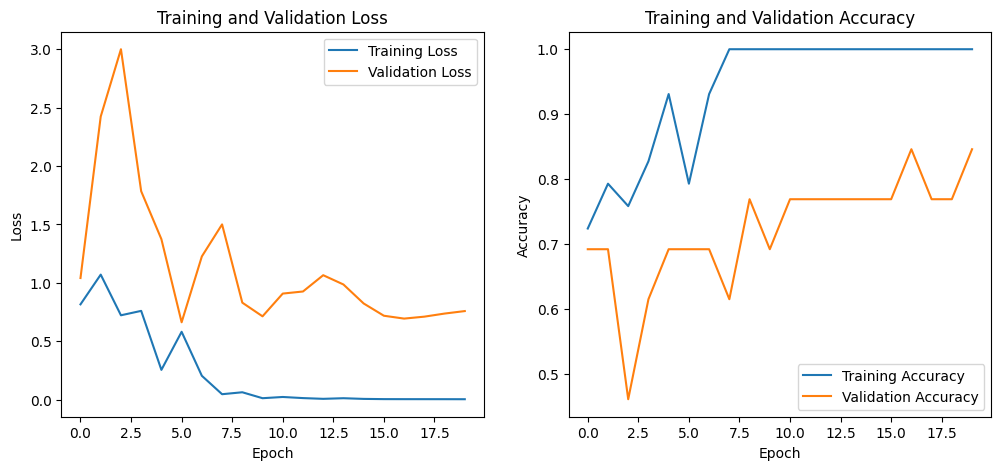

In [55]:
# Split the data into training and validation sets
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y_categorical, test_size=0.3, stratify=y)

import matplotlib.pyplot as plt

# Train the multi-class classifier and store the training history
history = multi_classifier.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_val, y_val)
)

# Plot the training and validation loss
def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Plot training & validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot training & validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

# Call the function to plot the history
plot_training_history(history)

In [56]:
# Evaluate the model on the validation set
loss, accuracy = multi_classifier.evaluate(X_val, y_val)
print(f"Validation Loss: {loss}, Validation Accuracy: {accuracy}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8462 - loss: 0.7584
Validation Loss: 0.7583640217781067, Validation Accuracy: 0.8461538553237915
